# Episodic TF enrichment

## Cellular program: Z11 ∪ Z3 (GC vs PB), not Z11 alone

The per-episode enrichment tables read below (`config.PB['ep1'..'ep4']`, `config.GC[...]`)
enrich the **union of the two GC-vs-PB state-discriminative latent factors, Z11 and Z3**, with
`HLA-` genes dropped (57 genes) -- the `z11_*` names on the figures and output folders are
historical. Verified 2026-09-11: only the union reproduces the enriched-TF sets and link table
below; Z11 alone gives 9 PB / 8 GC TFs with different membership.

Tables are produced by `run_episodic_enrichment_bcell.py` (this folder) with the fixed
`focalfire.temporal` code (ISSUES #1 and #3): PB = (1, 2), GC = (1, 3), 20 sampled points,
5 per episode, `dist=0.001`, `sparsity=0.01`, p < 1e-3 edge filter, top 98th percentile of
|mean force|, direct-effect network `w`. The pre-fix June 2025 tables are archived next to
them in `legacy_jun2025_prefix_bug/` and must not be used.

In [1]:
# Dataset locations for this notebook come from ../datasets.yaml.
# Edit that file to point at your own copies -- do not hardcode paths below.
from focalfire.io import DatasetPaths

# DatasetPaths.find() walks up from the kernel's working directory to the first
# datasets.yaml (or uses $FIREFATE_DATASETS), so it works wherever Jupyter was started.
config = DatasetPaths.find()


In [2]:
import numpy as np
import pandas as pd
import os
import joblib
import pickle
import math
import ast
from scipy.stats import median_abs_deviation, hypergeom, mannwhitneyu
from scipy.cluster.hierarchy import linkage, dendrogram, leaves_list
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
# Saving plots with editable text
plt.rcParams['pdf.fonttype'] = 42  # TrueType fonts (editable text)

In [3]:
import dictys

from focalfire.temporal import *      # classes AND their figures
from focalfire.utils import *         # gene / state helpers (was utils_custom)

In [4]:
import importlib
import focalfire.temporal._episodes
importlib.reload(focalfire.temporal._episodes)
importlib.reload(focalfire.temporal)
from focalfire.temporal import *          # re-bind names into the notebook namespace

# Episodic enrichment plots

In [5]:
df_pb_ep1 = pd.read_csv(config.PB['ep1'])
df_pb_ep2 = pd.read_csv(config.PB['ep2'])
df_pb_ep3 = pd.read_csv(config.PB['ep3'])
df_pb_ep4 = pd.read_csv(config.PB['ep4'])

In [6]:
df_gc_ep1 = pd.read_csv(config.GC['ep1'])
df_gc_ep2 = pd.read_csv(config.GC['ep2'])
df_gc_ep3 = pd.read_csv(config.GC['ep3'])
df_gc_ep4 = pd.read_csv(config.GC['ep4'])

Filtered to 35 TFs that meet gene count criteria
Further filtered to 10 TFs that meet significance threshold < 0.05


/ocean/projects/cis240075p/asachan/methods/focalfire_codebases/focalfire/src/focalfire/temporal/_episodes.py:957: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


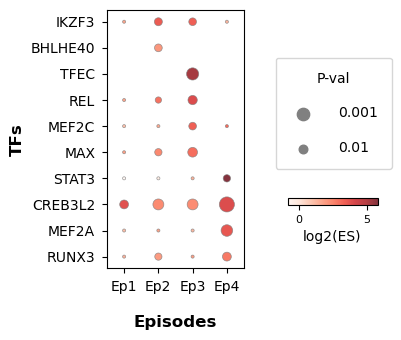

In [7]:
episode_labels=['Ep1', 'Ep2', 'Ep3', 'Ep4']

# Use it in the plot
fig, plot_data, plotted_tfs_pb = plot_tf_episodic_enrichment_dotplot(
    dfs=[df_pb_ep1, df_pb_ep2, df_pb_ep3, df_pb_ep4],
    episode_labels=episode_labels,
    figsize=(4.5, 3.5), #breadth by length
    p_value_threshold=0.05,
    min_significance_threshold=0.05,
    min_dot_size=10,
    max_dot_size=200,
    cmap_name="Reds",
    tf_order=None,
    figure_title=None,
    log_scale=True,
    horizontal_layout=False
)
# save the plot
fig.savefig(os.path.join(config.OUTPUT_FOLDER, "z11_pb_ee_005.pdf"), dpi=300)

Filtered to 41 TFs that meet gene count criteria
Further filtered to 11 TFs that meet significance threshold < 0.05


/ocean/projects/cis240075p/asachan/methods/focalfire_codebases/focalfire/src/focalfire/temporal/_episodes.py:957: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


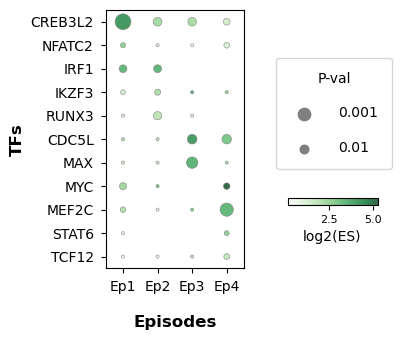

In [8]:
episode_labels=['Ep1', 'Ep2', 'Ep3', 'Ep4']

# Use it in the plot
fig, plot_data, plotted_tfs_gc = plot_tf_episodic_enrichment_dotplot(
    dfs=[df_gc_ep1, df_gc_ep2, df_gc_ep3, df_gc_ep4],
    episode_labels=episode_labels,
    figsize=(4.5, 3.5), #breadth by length
    p_value_threshold=0.05,
    min_significance_threshold=0.05,
    min_dot_size=10,    
    max_dot_size=200,   
    cmap_name="Greens",
    tf_order=None,
    figure_title=None,
    log_scale=True,
    horizontal_layout=False
)
# save the plot
fig.savefig(os.path.join(config.OUTPUT_FOLDER, "z11_gc_ee_005.pdf"), dpi=300)

## Episodic links

In [9]:
# For each enriched (plotted) TF, list its LF target genes (genes_in_lf) ONLY in the
# episodes where it actually passed the enrichment threshold in the dotplot.
# Per-episode threshold matches the dotplot calls above: PB=0.05 (cell 8), GC=0.05 (cell 9).
# A dot is "enriched" when p_value <= p_value_threshold; otherwise it is shrunk to min_dot_size*0.5.
# TF order follows the dotplot (peak episode first, then decreasing peak ES), not the alphabet.
PB_PVAL_THRESHOLD = 0.05
GC_PVAL_THRESHOLD = 0.05

def parse_genes_in_lf(genes_str):
    try:
        if pd.isna(genes_str) or genes_str in ('', '()'):
            return ()
        val = ast.literal_eval(genes_str)
        return val if isinstance(val, tuple) else (val,)
    except Exception:
        return ()

def collect_lf_targets(dfs_by_episode, enriched_tfs, lineage, p_value_threshold):
    # enriched_tfs is the dotplot's own TF order (its 3rd return value): TFs peaking in
    # Ep1 first, then Ep2, ..., and within a block by decreasing peak ES.
    tf_rank = {tf: i for i, tf in enumerate(enriched_tfs)}
    rows = []
    for episode, df in dfs_by_episode.items():
        sub = df[(df['TF'].isin(tf_rank.keys())) & (df['p_value'] <= p_value_threshold)]
        for _, r in sub.iterrows():
            genes = parse_genes_in_lf(r['genes_in_lf'])
            if not genes:                      # enriched episode but no LF target genes -> no link
                continue
            rows.append({
                'lineage': lineage,
                'episode': episode,
                'TF': r['TF'],
                'tf_rank': tf_rank[r['TF']],
                'enrichment_score': r['enrichment_score'],
                'p_value': r['p_value'],
                'genes_in_lf': ', '.join(genes),
                'n_genes_in_lf': len(genes),
            })
    return rows

pb_dfs = {'Ep1': df_pb_ep1, 'Ep2': df_pb_ep2, 'Ep3': df_pb_ep3, 'Ep4': df_pb_ep4}
gc_dfs = {'Ep1': df_gc_ep1, 'Ep2': df_gc_ep2, 'Ep3': df_gc_ep3, 'Ep4': df_gc_ep4}

enriched_tf_lf_targets = (
    pd.DataFrame(
        collect_lf_targets(pb_dfs, plotted_tfs_pb, 'PB', PB_PVAL_THRESHOLD)
        + collect_lf_targets(gc_dfs, plotted_tfs_gc, 'GC', GC_PVAL_THRESHOLD)
    )
    .sort_values(['lineage', 'tf_rank', 'episode'])
    .drop(columns='tf_rank')
    .reset_index(drop=True)
)

display(enriched_tf_lf_targets)

out_path = os.path.join(config.OUTPUT_FOLDER, "enriched_tf_lf_targets_per_episode.csv")
enriched_tf_lf_targets.to_csv(out_path, index=False)
print(f"Saved {len(enriched_tf_lf_targets)} rows to {out_path}")

,lineage,episode,TF,enrichment_score,p_value,genes_in_lf,n_genes_in_lf
0,GC,Ep1,CREB3L2,18.415459,0.000054,"HSP90B1, LMAN1, SSR1, TRAM1",4
1,GC,Ep2,CREB3L2,4.806638,0.009091,"HSP90B1, LMAN1, SSR1, TRAM1",4
2,GC,Ep3,CREB3L2,4.559441,0.010300,"HSP90B1, LMAN1, SSR1, TRAM1",4
3,GC,Ep4,CREB3L2,2.664454,0.023469,"FNDC3A, HSP90B1, LMAN1, SSR1, TRAM1, TXNDC5",6
4,GC,Ep1,NFATC2,6.228758,0.040411,"MAN1A1, TNFAIP8",2
5,GC,Ep4,NFATC2,2.243622,0.033651,"AFF3, CCSER2, DEK, IRF4, MAN1A1, SLC25A13, TXNDC5",7
6,GC,Ep1,IRF1,10.588889,0.014874,"RNF213, UBAC2",2
7,GC,Ep2,IRF1,11.101045,0.013604,"RNF213, UBAC2",2
8,GC,Ep1,IKZF3,2.533227,0.045511,"ANKRD28, CD74, MED23, PIKFYVE, RNF213",5
9,GC,Ep2,IKZF3,4.426366,0.029550,"ANKRD28, PIKFYVE, RNF213",3


Saved 37 rows to /ocean/projects/cis240075p/asachan/datasets/B_Cell/multiome_1st_donor_UPMC_aggr/dictys_outs/actb1_added_v2/output/figures/enriched_tf_lf_targets_per_episode.csv


### Bar plots of ES and target split between states

saved /ocean/projects/cis240075p/asachan/datasets/B_Cell/multiome_1st_donor_UPMC_aggr/dictys_outs/actb1_added_v2/output/figures/z11_episodic_enrichment/z11_gc_es_bars_ep1.pdf
saved /ocean/projects/cis240075p/asachan/datasets/B_Cell/multiome_1st_donor_UPMC_aggr/dictys_outs/actb1_added_v2/output/figures/z11_episodic_enrichment/z11_gc_es_bars_ep2.pdf


saved /ocean/projects/cis240075p/asachan/datasets/B_Cell/multiome_1st_donor_UPMC_aggr/dictys_outs/actb1_added_v2/output/figures/z11_episodic_enrichment/z11_gc_es_bars_ep3.pdf


saved /ocean/projects/cis240075p/asachan/datasets/B_Cell/multiome_1st_donor_UPMC_aggr/dictys_outs/actb1_added_v2/output/figures/z11_episodic_enrichment/z11_gc_es_bars_ep4.pdf
saved /ocean/projects/cis240075p/asachan/datasets/B_Cell/multiome_1st_donor_UPMC_aggr/dictys_outs/actb1_added_v2/output/figures/z11_episodic_enrichment/z11_pb_es_bars_ep1.pdf


saved /ocean/projects/cis240075p/asachan/datasets/B_Cell/multiome_1st_donor_UPMC_aggr/dictys_outs/actb1_added_v2/output/figures/z11_episodic_enrichment/z11_pb_es_bars_ep2.pdf
saved /ocean/projects/cis240075p/asachan/datasets/B_Cell/multiome_1st_donor_UPMC_aggr/dictys_outs/actb1_added_v2/output/figures/z11_episodic_enrichment/z11_pb_es_bars_ep3.pdf


saved /ocean/projects/cis240075p/asachan/datasets/B_Cell/multiome_1st_donor_UPMC_aggr/dictys_outs/actb1_added_v2/output/figures/z11_episodic_enrichment/z11_pb_es_bars_ep4.pdf


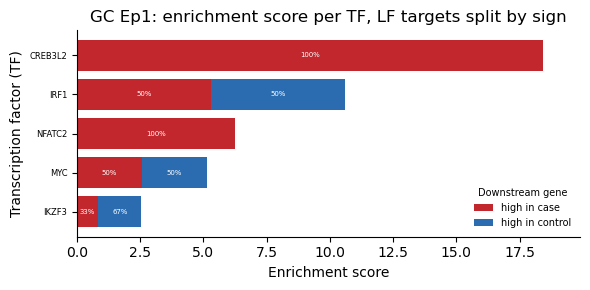

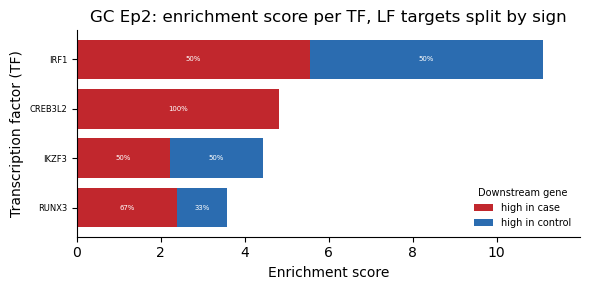

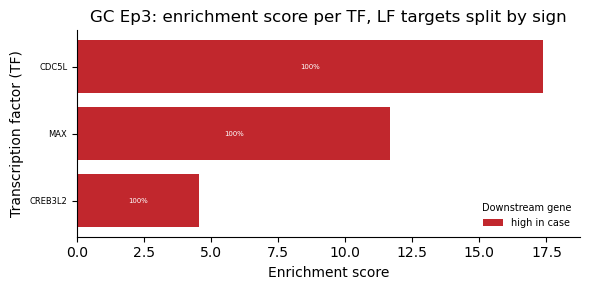

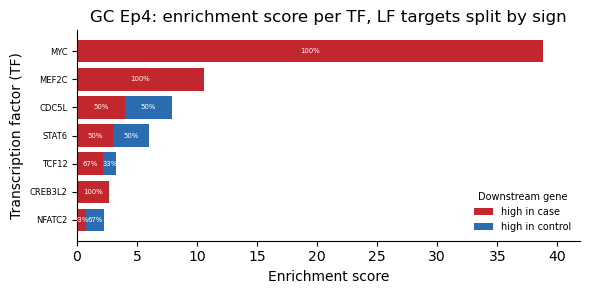

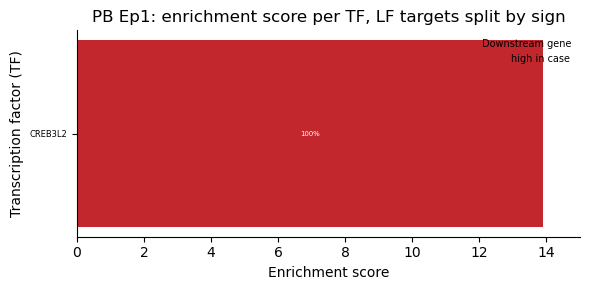

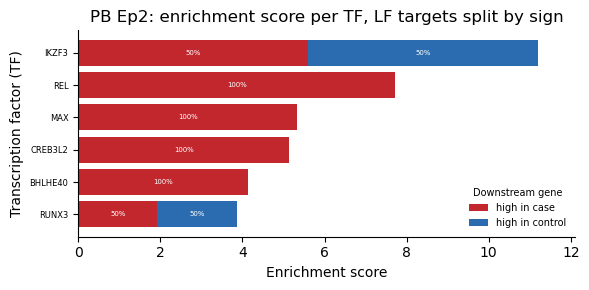

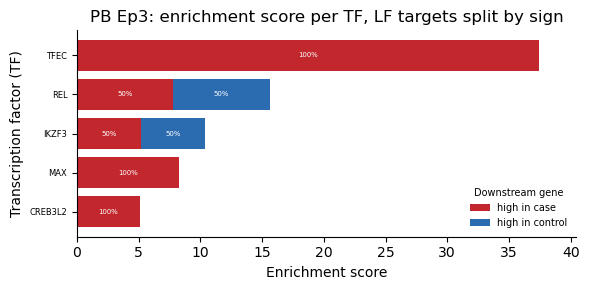

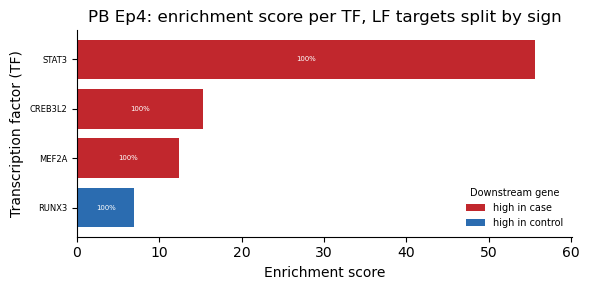

In [10]:
from focalfire.io import load_lf_gene_colors
from focalfire.state_specific import build_tf_color_bar_table, plot_tf_enrichment_bars

# Red = positively correlated Z11 gene, blue = negatively correlated.
LF_FEATURE_FILES = [config.LF_Z11_GC_PB]
gene_colors = load_lf_gene_colors(LF_FEATURE_FILES)

ES_BAR_DIR = config.ES_BAR_DIR

def es_bar_plot(sub, lineage, episode):
    """Bar height = enrichment score; stack = that TF's LF targets split by LF sign."""
    links = pd.DataFrame(
        [{'source': r['TF'], 'target': g}
         for _, r in sub.iterrows()
         for g in r['genes_in_lf'].split(', ')
         if g in gene_colors],                      # LF genes only -> no gray segment
        columns=['source', 'target'],
    ).drop_duplicates()
    if links.empty:
        print(f"{lineage} {episode}: no LF targets, skipped")
        return None
    plot_df = build_tf_color_bar_table(
        links,
        sub[['TF', 'enrichment_score']].rename(columns={'enrichment_score': 'score'}),
        gene_colors,
    )
    out_path = os.path.join(ES_BAR_DIR, f"z11_{lineage.lower()}_es_bars_{episode.lower()}.pdf")
    fig, _ = plot_tf_enrichment_bars(
        plot_df,
        f"{lineage} {episode}: enrichment score per TF, LF targets split by sign",
        out_path=out_path,           # folder is created by plot_tf_enrichment_bars
    )
    print(f"saved {out_path}")
    return plot_df

es_bar_tables = {
    (lineage, episode): es_bar_plot(sub, lineage, episode)
    for (lineage, episode), sub in enriched_tf_lf_targets.groupby(['lineage', 'episode'])
}

# Shape of TF expression curves for each of the enriched TFs

In [11]:
# Load data
dictys_dynamic_object = dictys.net.dynamic_network.from_file(config.DYNAMIC_H5)

In [12]:
branches = {'PlasmaBlast': (0, 2), 'GerminalCenter': (0, 3)}

def classify_branch(branch_to_plot, tf_list, mode="expression"):
    """Wave-pattern classification of TF expression shape for one branch."""
    rng = branches[branch_to_plot]
    sc = SmoothedCurvesGRN(dictys_dynamic_object, trajectory_range=rng,
        num_points=100, dist=0.0005, sparsity=0.01, mode=mode)
    dy, dx = sc.get_smoothed_curves()
    df = sc.classify_wave_patterns(dx.values, dy, tf_list=tf_list)
    df["branch"] = branch_to_plot
    return df

In [13]:
state_specific_tfs_pb = ['CREB3L2', 'XBP1', 'PRDM1', 'IRF4', 'RUNX2', 'HERPUD1', 'HIVEP2', 'ARID5B', 'TFEC', 'TCF12', 'AFF1']

In [14]:
expression_shape_df_pb = classify_branch('PlasmaBlast', plotted_tfs_pb, mode="expression")
expression_shape_df_pb[["branch", "trajectory", "wave_pattern"]]

,branch,trajectory,wave_pattern
BHLHE40,PlasmaBlast,"(0, 2)",down
CREB3L2,PlasmaBlast,"(0, 2)",up
IKZF3,PlasmaBlast,"(0, 2)",transiently_up
MAX,PlasmaBlast,"(0, 2)",transiently_up
MEF2A,PlasmaBlast,"(0, 2)",transiently_up
MEF2C,PlasmaBlast,"(0, 2)",transiently_up
REL,PlasmaBlast,"(0, 2)",down
RUNX3,PlasmaBlast,"(0, 2)",down
STAT3,PlasmaBlast,"(0, 2)",down
TFEC,PlasmaBlast,"(0, 2)",down


In [15]:
expression_shape_df_gc = classify_branch('GerminalCenter', plotted_tfs_gc)
expression_shape_df_gc[["branch", "trajectory", "wave_pattern"]]

,branch,trajectory,wave_pattern
CDC5L,GerminalCenter,"(0, 3)",up
CREB3L2,GerminalCenter,"(0, 3)",transiently_up
IKZF3,GerminalCenter,"(0, 3)",transiently_up
IRF1,GerminalCenter,"(0, 3)",down
MAX,GerminalCenter,"(0, 3)",down
MEF2C,GerminalCenter,"(0, 3)",up
MYC,GerminalCenter,"(0, 3)",down
NFATC2,GerminalCenter,"(0, 3)",transiently_up
RUNX3,GerminalCenter,"(0, 3)",up
STAT6,GerminalCenter,"(0, 3)",transiently_down


# Branch with higher expression of the enriched TFs

In [16]:
# Which branch has the higher expression of the episodically enriched TFs
# (the TFs that went into the wave-pattern classification above)?
# Same smoothing as classify_branch (100 points, dist=0.0005). Both ranges start at the
# branch node (node 0), so every sampled point is post-bifurcation; mean and max are
# taken over the whole branch curve. Curves are log2 CPM, so PB - GC is a log2 fold change.
enriched_tfs = sorted(set(plotted_tfs_pb) | set(plotted_tfs_gc))

branch_expr = {}
for branchname, rng in branches.items():
    sc = SmoothedCurvesGRN(dictys_dynamic_object, trajectory_range=rng,
        num_points=100, dist=0.0005, sparsity=0.01, mode="expression")
    dy, dx = sc.get_smoothed_curves()
    dy = dy.loc[dy.index.intersection(enriched_tfs)]
    branch_expr[branchname] = pd.DataFrame({'mean': dy.mean(axis=1), 'max': dy.max(axis=1)})

branch_expr_df = pd.DataFrame({
    'PB_mean_log2cpm': branch_expr['PlasmaBlast']['mean'],
    'GC_mean_log2cpm': branch_expr['GerminalCenter']['mean'],
    'PB_max_log2cpm': branch_expr['PlasmaBlast']['max'],
    'GC_max_log2cpm': branch_expr['GerminalCenter']['max'],
})
branch_expr_df['log2FC_PB_vs_GC'] = branch_expr_df['PB_mean_log2cpm'] - branch_expr_df['GC_mean_log2cpm']
branch_expr_df['higher_in'] = np.where(branch_expr_df['log2FC_PB_vs_GC'] > 0, 'PB', 'GC')
branch_expr_df['enriched_in'] = [
    'PB+GC' if tf in plotted_tfs_pb and tf in plotted_tfs_gc else 'PB' if tf in plotted_tfs_pb else 'GC'
    for tf in branch_expr_df.index]
branch_expr_df['PB_wave_pattern'] = expression_shape_df_pb['wave_pattern'].reindex(branch_expr_df.index)
branch_expr_df['GC_wave_pattern'] = expression_shape_df_gc['wave_pattern'].reindex(branch_expr_df.index)
branch_expr_df = branch_expr_df.round(3).sort_values('log2FC_PB_vs_GC', ascending=False)
display(branch_expr_df)


,PB_mean_log2cpm,GC_mean_log2cpm,PB_max_log2cpm,GC_max_log2cpm,log2FC_PB_vs_GC,higher_in,enriched_in,PB_wave_pattern,GC_wave_pattern
CREB3L2,7.273,6.114,8.256,6.288,1.159,PB,PB+GC,up,transiently_up
IRF1,7.122,6.349,7.561,7.360,0.773,PB,GC,NaN,down
TCF12,9.182,9.072,9.257,9.155,0.111,PB,GC,NaN,transiently_up
MAX,6.460,6.395,6.700,6.529,0.065,PB,PB+GC,transiently_up,down
IKZF3,9.038,8.983,9.182,9.043,0.055,PB,PB+GC,transiently_up,transiently_up
MEF2A,9.102,9.337,9.381,9.756,-0.235,GC,PB,transiently_up,NaN
CDC5L,6.605,6.855,6.782,6.915,-0.250,GC,GC,NaN,up
STAT3,7.867,8.155,8.671,8.692,-0.288,GC,PB,down,NaN
MEF2C,9.817,10.128,10.195,10.416,-0.311,GC,PB+GC,transiently_up,up
RUNX3,8.459,8.796,9.101,8.855,-0.337,GC,PB+GC,down,up
